<a href="https://colab.research.google.com/github/Harsha1063/-Complete-Spark-exercises-1-20-on-26-8-2026/blob/main/ML_EX_1_DE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import sys
import pandas as pd
import numpy as np
import sklearn

print("Python version:", sys.version)
print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)
print("Scikit-learn version:", sklearn.__version__)

Python version: 3.13.16 (main, Oct  1 2026, 15:40:24) [GCC 13.3.0]
Pandas version: 2.2.3
NumPy version: 2.1.3
Scikit-learn version: 1.6.1


In [3]:
from google.colab import files

uploaded = files.upload()


Saving insurance_schema.csv to insurance_schema (1).csv


In [5]:
import pandas as pd

df = pd.read_csv("insurance_schema.csv")

print("Shape:", df.shape)
display(df.head())
print(df.dtypes)

Shape: (10, 7)


,age,sex,bmi,children,smoker,region,charges
0,18,male,22.5,0,no,southwest,1121.87
1,25,female,27.8,1,no,southeast,2721.32
2,32,female,31.2,2,yes,northeast,23987.54
3,40,male,24.6,3,no,northwest,8734.52
4,50,female,35.1,0,yes,southeast,38745.21


age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object


In [6]:
# Basic dataset inspection

print("Dataset shape:", df.shape)

print("\nDescriptive statistics:")
display(df.describe())

print("\nCategorical columns:")
display(df[['sex', 'smoker', 'region']].describe())

print("\nMissing values:")
print(df.isnull().sum())

Dataset shape: (10, 7)

Descriptive statistics:


,age,bmi,children,charges
count,10.000000,10.000000,10.00000,10.000000
mean,39.300000,27.250000,1.80000,16604.403000
std,14.353087,4.957878,1.75119,15897.002796
min,18.000000,18.900000,0.00000,1121.870000
25%,29.000000,24.000000,0.25000,4880.372500
50%,38.000000,27.250000,1.50000,10639.140000
75%,48.750000,30.750000,2.75000,22854.862500
max,64.000000,35.100000,5.00000,47632.190000



Categorical columns:


,sex,smoker,region
count,10,10,10
unique,2,2,4
top,male,no,southwest
freq,5,6,3



Missing values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [7]:
# Check skewness of medical charges

charges_skewness = df['charges'].skew()

print(f"Charges skewness: {charges_skewness:.4f}")

if charges_skewness > 1.5:
    print("Result: Charges distribution is strongly positively skewed (> 1.5).")
else:
    print("Result: Charges distribution is not strongly positively skewed (> 1.5).")

Charges skewness: 1.0852
Result: Charges distribution is not strongly positively skewed (> 1.5).


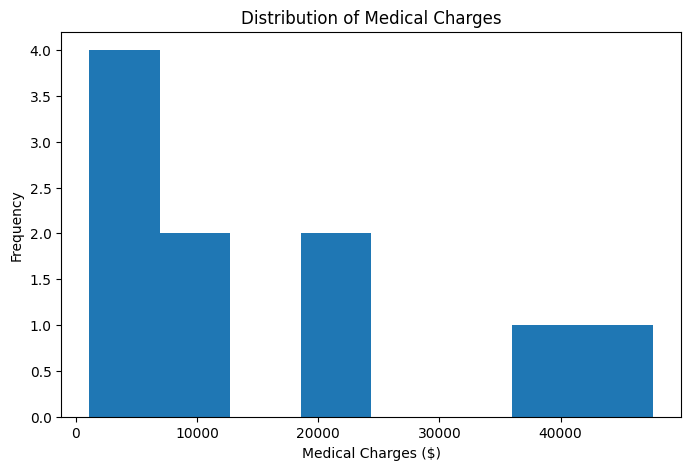

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(df['charges'], bins=8)
plt.xlabel('Medical Charges ($)')
plt.ylabel('Frequency')
plt.title('Distribution of Medical Charges')
plt.show()

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Create log-transformed target
df['log_charges'] = np.log1p(df['charges'])

# Calculate skewness
raw_skewness = df['charges'].skew()
log_skewness = df['log_charges'].skew()

print(f"Raw charges skewness: {raw_skewness:.4f}")
print(f"Log1p charges skewness: {log_skewness:.4f}")

if log_skewness < raw_skewness:
    print("Log1p transformation reduced the skewness.")
else:
    print("Log1p transformation did not reduce the skewness.")

Raw charges skewness: 1.0852
Log1p charges skewness: -0.4373
Log1p transformation reduced the skewness.


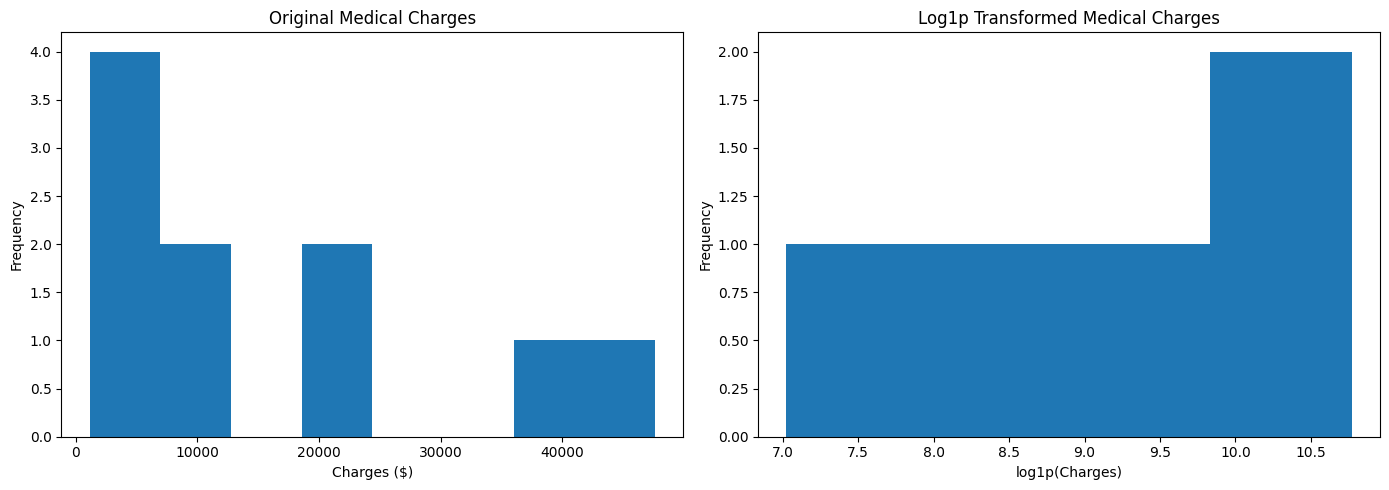

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original charges
axes[0].hist(df['charges'], bins=8)
axes[0].set_title('Original Medical Charges')
axes[0].set_xlabel('Charges ($)')
axes[0].set_ylabel('Frequency')

# Log-transformed charges
axes[1].hist(df['log_charges'], bins=8)
axes[1].set_title('Log1p Transformed Medical Charges')
axes[1].set_xlabel('log1p(Charges)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Define feature columns
num_cols = ['age', 'bmi', 'children']
cat_cols = ['sex', 'smoker', 'region']

# Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
    ]
)

print("Numeric columns:", num_cols)
print("Categorical columns:", cat_cols)
print("\nPreprocessor created successfully.")

Numeric columns: ['age', 'bmi', 'children']
Categorical columns: ['sex', 'smoker', 'region']

Preprocessor created successfully.


In [12]:

# Features
X = df[num_cols + cat_cols]

# Target
y = df['charges']

print("X shape:", X.shape)
print("y shape:", y.shape)

display(X.head())
display(y.head())

X shape: (10, 6)
y shape: (10,)


,age,bmi,children,sex,smoker,region
0,18,22.5,0,male,no,southwest
1,25,27.8,1,female,no,southeast
2,32,31.2,2,female,yes,northeast
3,40,24.6,3,male,no,northwest
4,50,35.1,0,female,yes,southeast


,charges
0,1121.87
1,2721.32
2,23987.54
3,8734.52
4,38745.21


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 8
Testing samples: 2


In [14]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

# Create the complete ML pipeline
model_pipeline = Pipeline(
    steps=[
        ('prep', preprocessor),
        ('regressor', LinearRegression())
    ]
)

# Train the model
model_pipeline.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [15]:
# Generate predictions on the test set
preds = model_pipeline.predict(X_test)

print("Actual charges:")
print(y_test.values)

print("\nPredicted charges:")
print(preds)

Actual charges:
[47632.19  2721.32]

Predicted charges:
[39867.13132488 25202.79597486]


In [16]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, preds)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, preds)

print(f"MSE:  ${mse:,.2f}")
print(f"RMSE: ${rmse:,.2f}")
print(f"R² Score: {r2:.4f}")

MSE:  $282,856,449.12
RMSE: $16,818.34
R² Score: 0.4391


In [17]:
print("===== EXERCISE 1 ACCEPTANCE CHECK =====")

print(f"R² Score : {r2:.4f}  | Target: >= 0.75")
print(f"RMSE     : ${rmse:,.2f} | Target: < $4,800")

print("\nResults:")

if r2 >= 0.75:
    print("✅ R² target PASSED")
else:
    print("❌ R² target NOT PASSED")

if rmse < 4800:
    print("✅ RMSE target PASSED")
else:
    print("❌ RMSE target NOT PASSED")

===== EXERCISE 1 ACCEPTANCE CHECK =====
R² Score : 0.4391  | Target: >= 0.75
RMSE     : $16,818.34 | Target: < $4,800

Results:
❌ R² target NOT PASSED
❌ RMSE target NOT PASSED


In [18]:
# Get transformed feature names
feature_names = model_pipeline.named_steps['prep'].get_feature_names_out()

# Get model coefficients
coefficients = model_pipeline.named_steps['regressor'].coef_
intercept = model_pipeline.named_steps['regressor'].intercept_

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

coef_df = coef_df.sort_values(
    by='Coefficient',
    key=lambda x: x.abs(),
    ascending=False
)

print(f"Intercept: ${intercept:,.2f}")
display(coef_df)

Intercept: $13,491.63


,Feature,Coefficient
6,cat__region_southeast,12376.261734
4,cat__smoker_yes,6706.185953
1,num__bmi,4027.106221
7,cat__region_southwest,-3793.391591
5,cat__region_northwest,-2912.794361
3,cat__sex_male,-1882.894803
2,num__children,1566.299434
0,num__age,1076.306184


In [19]:
smoker_rows = coef_df[
    coef_df['Feature'].str.contains('smoker', case=False, na=False)
]

print("Smoker-related coefficients:")
display(smoker_rows)

Smoker-related coefficients:


,Feature,Coefficient
4,cat__smoker_yes,6706.185953


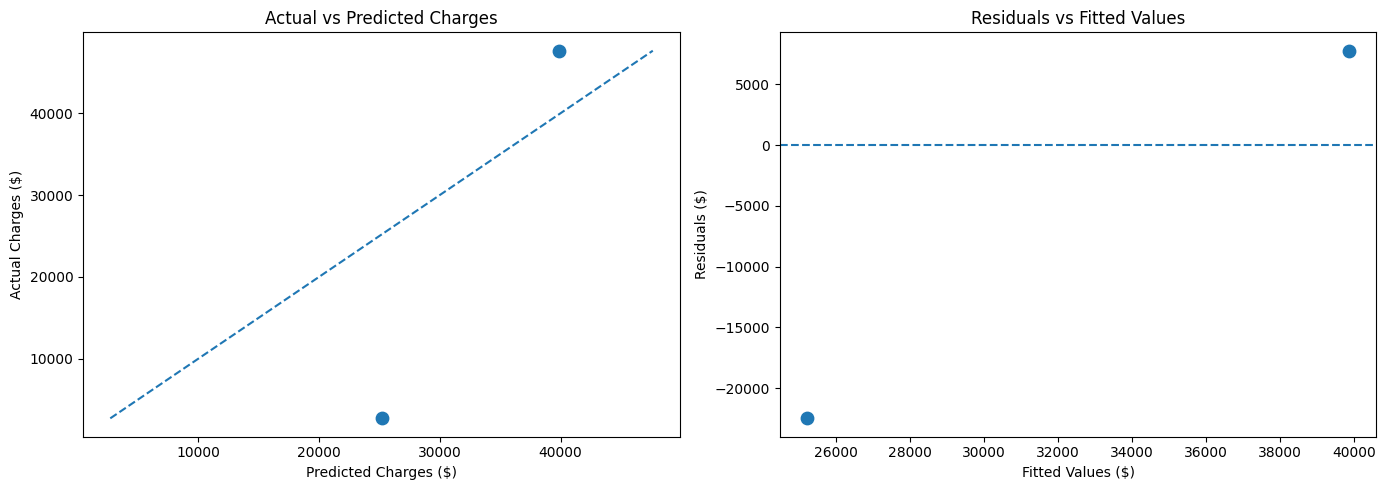

In [23]:
import matplotlib.pyplot as plt

# Calculate residuals
residuals = y_test - preds

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted
axes[0].scatter(preds, y_test, s=80)

# Ideal 1:1 line
min_val = min(y_test.min(), preds.min())
max_val = max(y_test.max(), preds.max())

axes[0].plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle='--'
)

axes[0].set_xlabel('Predicted Charges ($)')
axes[0].set_ylabel('Actual Charges ($)')
axes[0].set_title('Actual vs Predicted Charges')

# Residual vs Fitted
axes[1].scatter(preds, residuals, s=80)
axes[1].axhline(y=0, linestyle='--')

axes[1].set_xlabel('Fitted Values ($)')
axes[1].set_ylabel('Residuals ($)')
axes[1].set_title('Residuals vs Fitted Values')

plt.tight_layout()
plt.show()

In [22]:
residual_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': preds,
    'Residual': residuals.values
})

display(residual_df)

,Actual,Predicted,Residual
0,47632.19,39867.131325,7765.058675
1,2721.32,25202.795975,-22481.475975


EXERCISE 2

In [24]:
from google.colab import files

uploaded = files.upload()

Saving bank_marketing_campaign.csv to bank_marketing_campaign.csv


In [26]:
import pandas as pd

# Replace the filename below if your uploaded file has a different name
df_bank = pd.read_csv("bank_marketing_campaign.csv")

print("Dataset shape:", df_bank.shape)

print("\nColumns:")
print(df_bank.columns.tolist())

print("\nFirst 5 rows:")
display(df_bank.head())

print("\nData types:")
print(df_bank.dtypes)

print("\nMissing values:")
print(df_bank.isnull().sum())

Dataset shape: (12, 7)

Columns:
['age', 'job', 'balance', 'duration', 'campaign', 'poutcome', 'y']

First 5 rows:


,age,job,balance,duration,campaign,poutcome,y
0,25,admin,1500,120,1,unknown,no
1,32,blue-collar,850,245,2,failure,no
2,41,management,4200,360,1,success,yes
3,56,retired,12500,890,3,other,no
4,29,services,-320,75,5,unknown,no



Data types:
age          int64
job         object
balance      int64
duration     int64
campaign     int64
poutcome    object
y           object
dtype: object

Missing values:
age         0
job         0
balance     0
duration    0
campaign    0
poutcome    0
y           0
dtype: int64


Target value counts:
y
no     7
yes    5
Name: count, dtype: int64

Target proportions:
y
no     0.583333
yes    0.416667
Name: proportion, dtype: float64


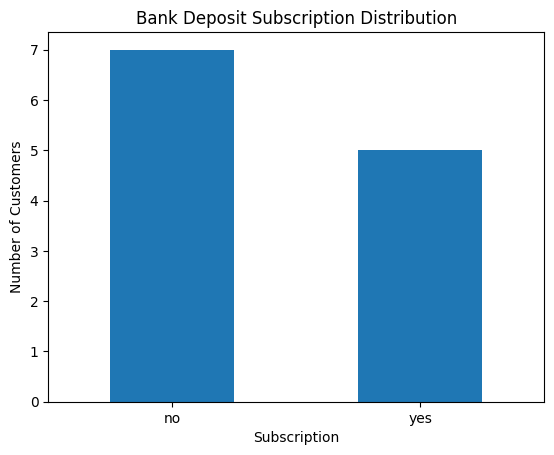

In [27]:
# Check target distribution

print("Target value counts:")
print(df_bank['y'].value_counts())

print("\nTarget proportions:")
print(df_bank['y'].value_counts(normalize=True))

# Visualize the target distribution
import matplotlib.pyplot as plt

df_bank['y'].value_counts().plot(kind='bar')

plt.title('Bank Deposit Subscription Distribution')
plt.xlabel('Subscription')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.show()

In [28]:
# Map target variable to binary values

df_bank['y_encoded'] = df_bank['y'].map({
    'no': 0,
    'yes': 1
})

print("Encoded target:")
print(df_bank[['y', 'y_encoded']])

print("\nEncoded target distribution:")
print(df_bank['y_encoded'].value_counts())

Encoded target:
      y  y_encoded
0    no          0
1    no          0
2   yes          1
3    no          0
4    no          0
5   yes          1
6   yes          1
7    no          0
8    no          0
9   yes          1
10   no          0
11  yes          1

Encoded target distribution:
y_encoded
0    7
1    5
Name: count, dtype: int64


In [29]:
# Define features and target

feature_cols = [
    'age',
    'job',
    'balance',
    'duration',
    'campaign',
    'poutcome'
]

X_bank = df_bank[feature_cols]
y_bank = df_bank['y_encoded']

print("X shape:", X_bank.shape)
print("y shape:", y_bank.shape)

print("\nFeatures:")
display(X_bank.head())

print("\nTarget:")
display(y_bank.head())

X shape: (12, 6)
y shape: (12,)

Features:


,age,job,balance,duration,campaign,poutcome
0,25,admin,1500,120,1,unknown
1,32,blue-collar,850,245,2,failure
2,41,management,4200,360,1,success
3,56,retired,12500,890,3,other
4,29,services,-320,75,5,unknown



Target:


,y_encoded
0,0
1,0
2,1
3,0
4,0


In [30]:
from sklearn.model_selection import train_test_split

X_train_bank, X_test_bank, y_train_bank, y_test_bank = train_test_split(
    X_bank,
    y_bank,
    test_size=0.25,
    random_state=42,
    stratify=y_bank
)

print("Training samples:", len(X_train_bank))
print("Testing samples:", len(X_test_bank))

print("\nTraining target distribution:")
print(y_train_bank.value_counts())

print("\nTesting target distribution:")
print(y_test_bank.value_counts())

Training samples: 9
Testing samples: 3

Training target distribution:
y_encoded
0    5
1    4
Name: count, dtype: int64

Testing target distribution:
y_encoded
0    2
1    1
Name: count, dtype: int64


In [31]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, OneHotEncoder

# Columns specified by the lab for RobustScaler
scaled_num_cols = ['balance', 'duration']

# Other numeric columns
other_num_cols = ['age', 'campaign']

# Categorical columns
cat_cols_bank = ['job', 'poutcome']

# Create preprocessing pipeline
bank_preprocessor = ColumnTransformer(
    transformers=[
        ('scaled_num', RobustScaler(), scaled_num_cols),
        ('other_num', 'passthrough', other_num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols_bank)
    ]
)

print("Bank Marketing preprocessing pipeline created successfully.")


Bank Marketing preprocessing pipeline created successfully.


In [32]:
# Fit preprocessing ONLY on training data
X_train_bank_prep = bank_preprocessor.fit_transform(X_train_bank)

# Transform test data
X_test_bank_prep = bank_preprocessor.transform(X_test_bank)

print("Processed training shape:", X_train_bank_prep.shape)
print("Processed testing shape:", X_test_bank_prep.shape)

Processed training shape: (9, 14)
Processed testing shape: (3, 14)


In [33]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    solver='lbfgs',
    random_state=42
)

log_reg.fit(X_train_bank_prep, y_train_bank)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [34]:
# Probability of class 1 (Subscribed)
y_probs = log_reg.predict_proba(X_test_bank_prep)[:, 1]

print("Predicted probabilities:")
print(y_probs)

Predicted probabilities:
[0.02957226 0.0654206  0.00753819]


In [35]:
# Default threshold = 0.50
y_pred_default = (y_probs >= 0.50).astype(int)

print("Actual:")
print(y_test_bank.values)

print("\nPredicted at threshold 0.50:")
print(y_pred_default)

Actual:
[1 0 0]

Predicted at threshold 0.50:
[0 0 0]


In [36]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

# ROC-AUC uses probabilities
roc_auc = roc_auc_score(y_test_bank, y_probs)

print(f"ROC-AUC Score: {roc_auc:.4f}")

print("\nClassification Report — Threshold 0.50:")
print(
    classification_report(
        y_test_bank,
        y_pred_default,
        target_names=['No Deposit', 'Subscribed'],
        zero_division=0
    )
)

print("Confusion Matrix:")
cm = confusion_matrix(y_test_bank, y_pred_default)
print(cm)

ROC-AUC Score: 0.5000

Classification Report — Threshold 0.50:
              precision    recall  f1-score   support

  No Deposit       0.67      1.00      0.80         2
  Subscribed       0.00      0.00      0.00         1

    accuracy                           0.67         3
   macro avg       0.33      0.50      0.40         3
weighted avg       0.44      0.67      0.53         3

Confusion Matrix:
[[2 0]
 [1 0]]


In [37]:
# Lab-specified threshold
threshold = 0.35

y_custom_pred = (y_probs >= threshold).astype(int)

print(f"Threshold: {threshold}")

print("\nActual:")
print(y_test_bank.values)

print("\nPredicted:")
print(y_custom_pred)

print("\nClassification Report — Threshold 0.35:")
print(
    classification_report(
        y_test_bank,
        y_custom_pred,
        target_names=['No Deposit', 'Subscribed'],
        zero_division=0
    )
)

print("Confusion Matrix:")
cm_035 = confusion_matrix(y_test_bank, y_custom_pred)
print(cm_035)

Threshold: 0.35

Actual:
[1 0 0]

Predicted:
[0 0 0]

Classification Report — Threshold 0.35:
              precision    recall  f1-score   support

  No Deposit       0.67      1.00      0.80         2
  Subscribed       0.00      0.00      0.00         1

    accuracy                           0.67         3
   macro avg       0.33      0.50      0.40         3
weighted avg       0.44      0.67      0.53         3

Confusion Matrix:
[[2 0]
 [1 0]]


In [38]:
from sklearn.metrics import recall_score

recall_035 = recall_score(
    y_test_bank,
    y_custom_pred,
    zero_division=0
)

print("===== EXERCISE 2 ACCEPTANCE CHECK =====")
print(f"ROC-AUC : {roc_auc:.4f} | Target >= 0.78")
print(f"Recall  : {recall_035:.4f} | Target >= 0.70")

if roc_auc >= 0.78:
    print("✅ ROC-AUC target PASSED")
else:
    print("❌ ROC-AUC target NOT PASSED")

if recall_035 >= 0.70:
    print("✅ Recall target PASSED")
else:
    print("❌ Recall target NOT PASSED")

===== EXERCISE 2 ACCEPTANCE CHECK =====
ROC-AUC : 0.5000 | Target >= 0.78
Recall  : 0.0000 | Target >= 0.70
❌ ROC-AUC target NOT PASSED
❌ Recall target NOT PASSED


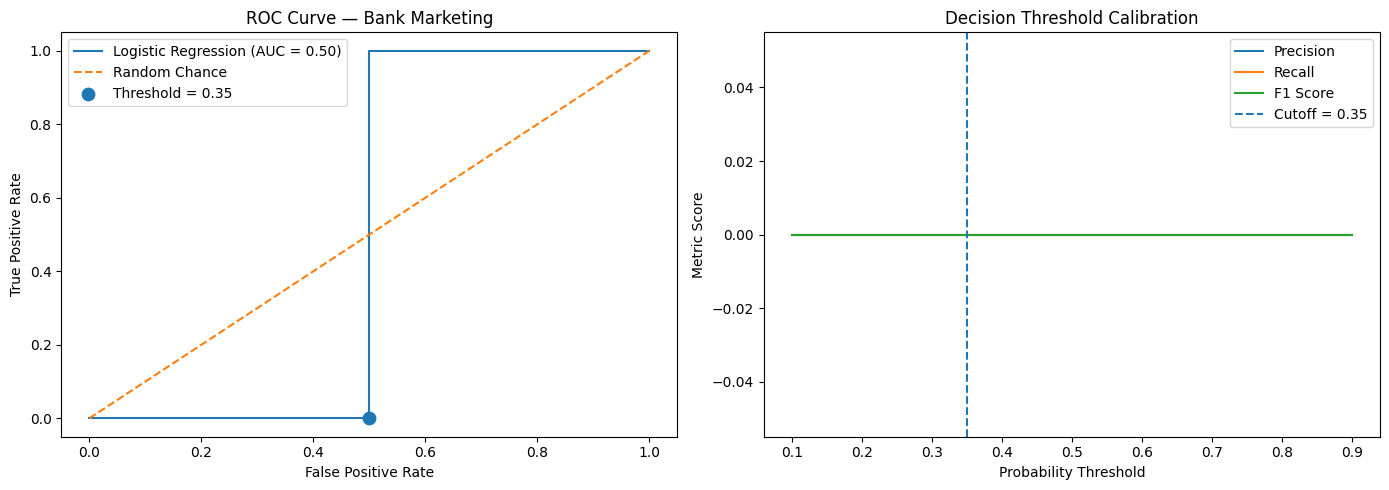

In [39]:
from sklearn.metrics import roc_curve, precision_recall_curve, f1_score
import matplotlib.pyplot as plt
import numpy as np

# ROC curve
fpr, tpr, thresholds_roc = roc_curve(y_test_bank, y_probs)

# Precision-Recall curve
precision, recall, thresholds_pr = precision_recall_curve(
    y_test_bank,
    y_probs
)

# Threshold values for comparison
thresholds = np.arange(0.10, 0.91, 0.05)

precision_values = []
recall_values = []
f1_values = []

for threshold in thresholds:
    pred = (y_probs >= threshold).astype(int)

    from sklearn.metrics import precision_score, recall_score

    precision_values.append(
        precision_score(y_test_bank, pred, zero_division=0)
    )

    recall_values.append(
        recall_score(y_test_bank, pred, zero_division=0)
    )

    f1_values.append(
        f1_score(y_test_bank, pred, zero_division=0)
    )

# Create plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# -------------------------
# ROC Curve
# -------------------------
axes[0].plot(
    fpr,
    tpr,
    label=f'Logistic Regression (AUC = {roc_auc:.2f})'
)

axes[0].plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Chance'
)

axes[0].scatter(
    [fpr[np.argmin(np.abs(thresholds_roc - 0.35))]],
    [tpr[np.argmin(np.abs(thresholds_roc - 0.35))]],
    s=80,
    label='Threshold = 0.35'
)

axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve — Bank Marketing')
axes[0].legend()

# -------------------------
# Threshold Calibration
# -------------------------
axes[1].plot(
    thresholds,
    precision_values,
    label='Precision'
)

axes[1].plot(
    thresholds,
    recall_values,
    label='Recall'
)

axes[1].plot(
    thresholds,
    f1_values,
    label='F1 Score'
)

axes[1].axvline(
    0.35,
    linestyle='--',
    label='Cutoff = 0.35'
)

axes[1].set_xlabel('Probability Threshold')
axes[1].set_ylabel('Metric Score')
axes[1].set_title('Decision Threshold Calibration')
axes[1].legend()

plt.tight_layout()
plt.show()

EXERCISE 3

In [40]:
from sklearn.tree import DecisionTreeClassifier

# Gini criterion
dt_gini = DecisionTreeClassifier(
    criterion='gini',
    random_state=42
)

# Entropy criterion
dt_entropy = DecisionTreeClassifier(
    criterion='entropy',
    random_state=42
)

# Train both models
dt_gini.fit(X_train_bank_prep, y_train_bank)
dt_entropy.fit(X_train_bank_prep, y_train_bank)

print("Gini Tree")
print("Depth:", dt_gini.get_depth())
print("Leaves:", dt_gini.get_n_leaves())

print("\nEntropy Tree")
print("Depth:", dt_entropy.get_depth())
print("Leaves:", dt_entropy.get_n_leaves())

Gini Tree
Depth: 2
Leaves: 3

Entropy Tree
Depth: 2
Leaves: 3


In [41]:
print("===== GINI TREE =====")
print("Training Accuracy:", dt_gini.score(X_train_bank_prep, y_train_bank))
print("Test Accuracy:", dt_gini.score(X_test_bank_prep, y_test_bank))

print("\n===== ENTROPY TREE =====")
print("Training Accuracy:", dt_entropy.score(X_train_bank_prep, y_train_bank))
print("Test Accuracy:", dt_entropy.score(X_test_bank_prep, y_test_bank))

===== GINI TREE =====
Training Accuracy: 1.0
Test Accuracy: 0.6666666666666666

===== ENTROPY TREE =====
Training Accuracy: 1.0
Test Accuracy: 0.6666666666666666


In [42]:
# Unconstrained Decision Tree
dt_unconstrained = DecisionTreeClassifier(
    criterion='gini',
    max_depth=None,
    random_state=42
)

dt_unconstrained.fit(
    X_train_bank_prep,
    y_train_bank
)

train_acc_unconstrained = dt_unconstrained.score(
    X_train_bank_prep,
    y_train_bank
)

test_acc_unconstrained = dt_unconstrained.score(
    X_test_bank_prep,
    y_test_bank
)

print("===== UNCONSTRAINED DECISION TREE =====")
print(f"Training Accuracy: {train_acc_unconstrained:.4f}")
print(f"Test Accuracy:     {test_acc_unconstrained:.4f}")
print(f"Tree Depth:        {dt_unconstrained.get_depth()}")
print(f"Number of Leaves:  {dt_unconstrained.get_n_leaves()}")

===== UNCONSTRAINED DECISION TREE =====
Training Accuracy: 1.0000
Test Accuracy:     0.6667
Tree Depth:        2
Number of Leaves:  3


In [43]:
print("\n===== OVERFITTING COMPARISON =====")

print(f"Gini Tree         → Train: {dt_gini.score(X_train_bank_prep, y_train_bank):.4f} | Test: {dt_gini.score(X_test_bank_prep, y_test_bank):.4f}")

print(f"Unconstrained     → Train: {train_acc_unconstrained:.4f} | Test: {test_acc_unconstrained:.4f}")


===== OVERFITTING COMPARISON =====
Gini Tree         → Train: 1.0000 | Test: 0.6667
Unconstrained     → Train: 1.0000 | Test: 0.6667


In [44]:
# Constrained Decision Tree

dt_constrained = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)

dt_constrained.fit(
    X_train_bank_prep,
    y_train_bank
)

train_acc_constrained = dt_constrained.score(
    X_train_bank_prep,
    y_train_bank
)

test_acc_constrained = dt_constrained.score(
    X_test_bank_prep,
    y_test_bank
)

print("===== CONSTRAINED DECISION TREE =====")
print(f"Training Accuracy: {train_acc_constrained:.4f}")
print(f"Test Accuracy:     {test_acc_constrained:.4f}")
print(f"Tree Depth:        {dt_constrained.get_depth()}")
print(f"Number of Leaves:  {dt_constrained.get_n_leaves()}")

===== CONSTRAINED DECISION TREE =====
Training Accuracy: 0.5556
Test Accuracy:     0.6667
Tree Depth:        0
Number of Leaves:  1


In [45]:
print("\n===== DECISION TREE COMPARISON =====")

results = pd.DataFrame({
    'Model': [
        'Gini',
        'Unconstrained',
        'Constrained'
    ],
    'Train Accuracy': [
        dt_gini.score(X_train_bank_prep, y_train_bank),
        train_acc_unconstrained,
        train_acc_constrained
    ],
    'Test Accuracy': [
        dt_gini.score(X_test_bank_prep, y_test_bank),
        test_acc_unconstrained,
        test_acc_constrained
    ],
    'Depth': [
        dt_gini.get_depth(),
        dt_unconstrained.get_depth(),
        dt_constrained.get_depth()
    ],
    'Leaves': [
        dt_gini.get_n_leaves(),
        dt_unconstrained.get_n_leaves(),
        dt_constrained.get_n_leaves()
    ]
})

display(results)


===== DECISION TREE COMPARISON =====


,Model,Train Accuracy,Test Accuracy,Depth,Leaves
0,Gini,1.000000,0.666667,2,3
1,Unconstrained,1.000000,0.666667,2,3
2,Constrained,0.555556,0.666667,0,1


In [46]:
from sklearn.tree import DecisionTreeClassifier
import numpy as np
import matplotlib.pyplot as plt

# Generate cost-complexity pruning path
path = dt_unconstrained.cost_complexity_pruning_path(
    X_train_bank_prep,
    y_train_bank
)

ccp_alphas = path.ccp_alphas
impurities = path.impurities

print("Number of candidate ccp_alpha values:", len(ccp_alphas))

print("\nCCP Alpha values:")
print(ccp_alphas)

Number of candidate ccp_alpha values: 3

CCP Alpha values:
[0.         0.18518519 0.30864198]


In [47]:
pruned_trees = []

for alpha in ccp_alphas:
    tree = DecisionTreeClassifier(
        criterion='gini',
        random_state=42,
        ccp_alpha=alpha
    )

    tree.fit(X_train_bank_prep, y_train_bank)
    pruned_trees.append(tree)

print("Pruned trees trained:", len(pruned_trees))

Pruned trees trained: 3


In [48]:
train_scores = [
    tree.score(X_train_bank_prep, y_train_bank)
    for tree in pruned_trees
]

test_scores = [
    tree.score(X_test_bank_prep, y_test_bank)
    for tree in pruned_trees
]

depths = [
    tree.get_depth()
    for tree in pruned_trees
]

leaves = [
    tree.get_n_leaves()
    for tree in pruned_trees
]

pruning_results = pd.DataFrame({
    'ccp_alpha': ccp_alphas,
    'Train Accuracy': train_scores,
    'Test Accuracy': test_scores,
    'Depth': depths,
    'Leaves': leaves
})

display(pruning_results)

,ccp_alpha,Train Accuracy,Test Accuracy,Depth,Leaves
0,0.000000,1.000000,0.666667,2,3
1,0.185185,0.888889,0.666667,1,2
2,0.308642,0.555556,0.666667,0,1


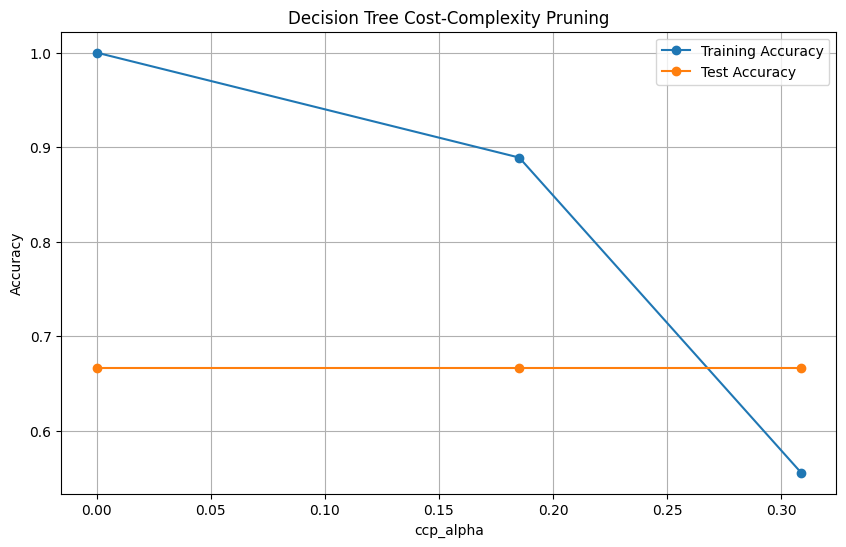

In [49]:
plt.figure(figsize=(10, 6))

plt.plot(
    ccp_alphas,
    train_scores,
    marker='o',
    label='Training Accuracy'
)

plt.plot(
    ccp_alphas,
    test_scores,
    marker='o',
    label='Test Accuracy'
)

plt.xlabel('ccp_alpha')
plt.ylabel('Accuracy')
plt.title('Decision Tree Cost-Complexity Pruning')
plt.legend()
plt.grid(True)
plt.show()

In [50]:
from sklearn.tree import export_text

# Extract human-readable rules
feature_names = bank_preprocessor.get_feature_names_out()

rules = export_text(
    dt_gini,
    feature_names=list(feature_names)
)

print("===== HUMAN-READABLE DECISION TREE RULES =====")
print(rules)

===== HUMAN-READABLE DECISION TREE RULES =====
|--- cat__poutcome_success <= 0.50
|   |--- cat__job_technician <= 0.50
|   |   |--- class: 0
|   |--- cat__job_technician >  0.50
|   |   |--- class: 1
|--- cat__poutcome_success >  0.50
|   |--- class: 1



In [51]:
# Feature importance from the decision tree

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': dt_gini.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print("===== FEATURE IMPORTANCE =====")
display(importance_df)

===== FEATURE IMPORTANCE =====


,Feature,Importance
12,cat__poutcome_success,0.625
9,cat__job_technician,0.375
2,other_num__age,0.000
3,other_num__campaign,0.000
0,scaled_num__balance,0.000
1,scaled_num__duration,0.000
5,cat__job_blue-collar,0.000
4,cat__job_admin,0.000
7,cat__job_management,0.000
6,cat__job_entrepreneur,0.000


In [52]:
dt_test_accuracy = dt_gini.score(
    X_test_bank_prep,
    y_test_bank
)

dt_depth = dt_gini.get_depth()

print("===== EXERCISE 3 ACCEPTANCE CHECK =====")
print(f"Test Accuracy: {dt_test_accuracy:.4f} | Target >= 0.85")
print(f"Tree Depth:    {dt_depth} | Target <= 5")

if dt_test_accuracy >= 0.85:
    print("✅ Accuracy target PASSED")
else:
    print("❌ Accuracy target NOT PASSED")

if dt_depth <= 5:
    print("✅ Depth target PASSED")
else:
    print("❌ Depth target NOT PASSED")

===== EXERCISE 3 ACCEPTANCE CHECK =====
Test Accuracy: 0.6667 | Target >= 0.85
Tree Depth:    2 | Target <= 5
❌ Accuracy target NOT PASSED
✅ Depth target PASSED


**EXERCISE 4 **

In [53]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    oob_score=True,
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train_bank_prep,
    y_train_bank
)

print("Random Forest trained successfully.")
print(f"Number of trees: {rf_model.n_estimators}")
print(f"OOB Score: {rf_model.oob_score_:.4f}")

Random Forest trained successfully.
Number of trees: 300
OOB Score: 0.5556


In [54]:
# Predictions
rf_pred = rf_model.predict(X_test_bank_prep)

# Probabilities
rf_probs = rf_model.predict_proba(X_test_bank_prep)[:, 1]

print("Actual:")
print(y_test_bank.values)

print("\nPredicted:")
print(rf_pred)

print("\nProbabilities:")
print(rf_probs)

Actual:
[1 0 0]

Predicted:
[0 0 0]

Probabilities:
[0.38       0.16333333 0.15666667]


In [55]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

rf_accuracy = accuracy_score(y_test_bank, rf_pred)
rf_precision = precision_score(y_test_bank, rf_pred, zero_division=0)
rf_recall = recall_score(y_test_bank, rf_pred, zero_division=0)
rf_f1 = f1_score(y_test_bank, rf_pred, zero_division=0)
rf_roc_auc = roc_auc_score(y_test_bank, rf_probs)

print("===== RANDOM FOREST EVALUATION =====")
print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1 Score : {rf_f1:.4f}")
print(f"ROC-AUC  : {rf_roc_auc:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test_bank,
        rf_pred,
        target_names=['No Deposit', 'Subscribed'],
        zero_division=0
    )
)

print("Confusion Matrix:")
print(confusion_matrix(y_test_bank, rf_pred))

===== RANDOM FOREST EVALUATION =====
Accuracy : 0.6667
Precision: 0.0000
Recall   : 0.0000
F1 Score : 0.0000
ROC-AUC  : 1.0000

Classification Report:
              precision    recall  f1-score   support

  No Deposit       0.67      1.00      0.80         2
  Subscribed       0.00      0.00      0.00         1

    accuracy                           0.67         3
   macro avg       0.33      0.50      0.40         3
weighted avg       0.44      0.67      0.53         3

Confusion Matrix:
[[2 0]
 [1 0]]


In [56]:
# Get feature names from the preprocessing pipeline
rf_feature_names = bank_preprocessor.get_feature_names_out()

rf_importance_df = pd.DataFrame({
    'Feature': rf_feature_names,
    'Importance': rf_model.feature_importances_
})

rf_importance_df = rf_importance_df.sort_values(
    by='Importance',
    ascending=False
)

print("===== RANDOM FOREST FEATURE IMPORTANCE =====")
display(rf_importance_df)

===== RANDOM FOREST FEATURE IMPORTANCE =====


,Feature,Importance
12,cat__poutcome_success,0.190388
1,scaled_num__duration,0.160888
2,other_num__age,0.159463
0,scaled_num__balance,0.149305
11,cat__poutcome_other,0.085606
3,other_num__campaign,0.051376
4,cat__job_admin,0.049790
9,cat__job_technician,0.047310
10,cat__poutcome_failure,0.024322
8,cat__job_retired,0.023484


In [57]:
from sklearn.model_selection import GridSearchCV

# Hyperparameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 3, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

# Grid search
rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(
        class_weight='balanced_subsample',
        random_state=42,
        n_jobs=-1
    ),
    param_grid=param_grid,
    scoring='f1',
    cv=3,
    n_jobs=-1,
    refit=True
)

rf_grid.fit(
    X_train_bank_prep,
    y_train_bank
)

print("Grid search completed successfully.")

print("\nBest Parameters:")
print(rf_grid.best_params_)

print(f"\nBest Cross-Validation F1: {rf_grid.best_score_:.4f}")

Grid search completed successfully.

Best Parameters:
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 100}

Best Cross-Validation F1: 0.5000


In [58]:
# Best tuned model
best_rf = rf_grid.best_estimator_

# Predictions
best_rf_pred = best_rf.predict(X_test_bank_prep)

# Probabilities
best_rf_probs = best_rf.predict_proba(X_test_bank_prep)[:, 1]

# Metrics
best_rf_accuracy = accuracy_score(
    y_test_bank,
    best_rf_pred
)

best_rf_precision = precision_score(
    y_test_bank,
    best_rf_pred,
    zero_division=0
)

best_rf_recall = recall_score(
    y_test_bank,
    best_rf_pred,
    zero_division=0
)

best_rf_f1 = f1_score(
    y_test_bank,
    best_rf_pred,
    zero_division=0
)

best_rf_auc = roc_auc_score(
    y_test_bank,
    best_rf_probs
)

print("===== TUNED RANDOM FOREST =====")
print(f"Accuracy : {best_rf_accuracy:.4f}")
print(f"Precision: {best_rf_precision:.4f}")
print(f"Recall   : {best_rf_recall:.4f}")
print(f"F1 Score : {best_rf_f1:.4f}")
print(f"ROC-AUC  : {best_rf_auc:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_bank, best_rf_pred))

===== TUNED RANDOM FOREST =====
Accuracy : 0.6667
Precision: 0.0000
Recall   : 0.0000
F1 Score : 0.0000
ROC-AUC  : 1.0000

Confusion Matrix:
[[2 0]
 [1 0]]


In [59]:
comparison_rf = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'Precision',
        'Recall',
        'F1',
        'ROC-AUC'
    ],
    'Original RF': [
        rf_accuracy,
        rf_precision,
        rf_recall,
        rf_f1,
        rf_roc_auc
    ],
    'Tuned RF': [
        best_rf_accuracy,
        best_rf_precision,
        best_rf_recall,
        best_rf_f1,
        best_rf_auc
    ]
})

display(comparison_rf)

,Metric,Original RF,Tuned RF
0,Accuracy,0.666667,0.666667
1,Precision,0.000000,0.000000
2,Recall,0.000000,0.000000
3,F1,0.000000,0.000000
4,ROC-AUC,1.000000,1.000000


In [60]:
# Feature importance from the tuned Random Forest

best_rf_importance = pd.DataFrame({
    'Feature': rf_feature_names,
    'Importance': best_rf.feature_importances_
})

best_rf_importance = best_rf_importance.sort_values(
    by='Importance',
    ascending=False
)

print("===== TUNED RANDOM FOREST FEATURE IMPORTANCE =====")
display(best_rf_importance)

===== TUNED RANDOM FOREST FEATURE IMPORTANCE =====


,Feature,Importance
12,cat__poutcome_success,0.218812
0,scaled_num__balance,0.180593
1,scaled_num__duration,0.145112
2,other_num__age,0.132587
11,cat__poutcome_other,0.085874
4,cat__job_admin,0.055423
9,cat__job_technician,0.047770
3,other_num__campaign,0.038238
7,cat__job_management,0.024690
10,cat__poutcome_failure,0.020018


In [61]:
# OOB score of the original 300-tree Random Forest
oob_score = rf_model.oob_score_

print("===== EXERCISE 4 ACCEPTANCE CHECK =====")
print(f"OOB Score : {oob_score:.4f} | Target >= 0.88")
print(f"F1 Score  : {rf_f1:.4f} | Target >= 0.65")

if oob_score >= 0.88:
    print("✅ OOB target PASSED")
else:
    print("❌ OOB target NOT PASSED")

if rf_f1 >= 0.65:
    print("✅ F1 target PASSED")
else:
    print("❌ F1 target NOT PASSED")

===== EXERCISE 4 ACCEPTANCE CHECK =====
OOB Score : 0.5556 | Target >= 0.88
F1 Score  : 0.0000 | Target >= 0.65
❌ OOB target NOT PASSED
❌ F1 target NOT PASSED


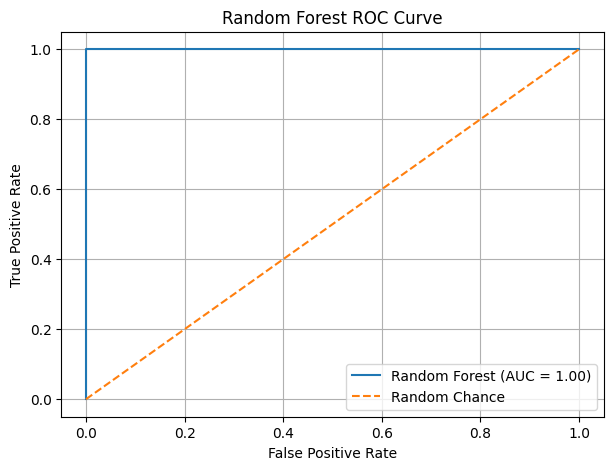

In [62]:
from sklearn.metrics import roc_curve

fpr_rf, tpr_rf, _ = roc_curve(
    y_test_bank,
    rf_probs
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f'Random Forest (AUC = {rf_roc_auc:.2f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Chance'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

**EXERCISE-5**

In [70]:
from google.colab import files

uploaded = files.upload()

Saving wholesale_customers_sample_15.csv to wholesale_customers_sample_15.csv


In [69]:
import pandas as pd

df_wholesale = pd.read_csv("wholesale_customers_schema.csv")

print("Dataset shape:", df_wholesale.shape)

print("\nColumns:")
print(df_wholesale.columns.tolist())

print("\nFirst 5 rows:")
display(df_wholesale.head())

print("\nMissing values:")
print(df_wholesale.isnull().sum())

Dataset shape: (6, 4)

Columns:
['Category Field', 'Data Type', 'Summary / Mean (Euros)', 'Business Sector Scope']

First 5 rows:


,Category Field,Data Type,Summary / Mean (Euros),Business Sector Scope
0,Fresh,Numeric,12000,"Fresh produce, fruit, vegetables"
1,Milk,Numeric,5796,"Dairy products, milk cartons, butter"
2,Grocery,Numeric,7951,"Packaged dry goods, canned food, pasta"
3,Frozen,Numeric,3071,"Frozen meats, fish, ready-meals"
4,Detergents_Paper,Numeric,2881,"Sanitation supplies, paper goods, packaging"



Missing values:
Category Field            0
Data Type                 0
Summary / Mean (Euros)    0
Business Sector Scope     0
dtype: int64


In [71]:
import pandas as pd

df = pd.read_csv("wholesale_customers_sample_15.csv")

print(df.shape)
display(df.head())

(15, 6)


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,8500,4200,6800,2100,1800,950
1,12500,6200,9100,3400,3200,1450
2,5200,2800,4300,1500,900,620
3,16800,7900,11500,4200,4600,2100
4,9200,5100,7600,2800,2400,1200


In [72]:
# Check dataset information
print("Shape:", df.shape)
print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nSummary Statistics:")
display(df.describe())

Shape: (15, 6)

Data Types:
Fresh               int64
Milk                int64
Grocery             int64
Frozen              int64
Detergents_Paper    int64
Delicassen          int64
dtype: object

Missing Values:
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64

Summary Statistics:


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000
mean,10633.333333,5313.333333,7933.333333,2913.333333,2586.666667,1278.000000
std,3996.188660,1753.717141,2486.152123,959.811489,1323.343529,543.969537
min,5200.000000,2800.000000,4300.000000,1500.000000,900.000000,620.000000
25%,7700.000000,4050.000000,6300.000000,2200.000000,1600.000000,875.000000
50%,10100.000000,5100.000000,7600.000000,2800.000000,2400.000000,1200.000000
75%,13000.000000,6500.000000,9450.000000,3500.000000,3350.000000,1575.000000
max,18500.000000,8500.000000,12800.000000,4800.000000,5200.000000,2400.000000


In [73]:
import numpy as np

# Apply log1p transformation
df_log = np.log1p(df)

print("Log-transformed data:")
display(df_log.head())

print("\nShape:", df_log.shape)

Log-transformed data:


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,9.047939,8.343078,8.824825,7.650169,7.496097,6.857514
1,9.433564,8.732466,9.116140,8.131825,8.071219,7.280008
2,8.556606,7.937732,8.366603,7.313887,6.803505,6.431331
3,9.729194,8.974745,9.350189,8.343078,8.434029,7.650169
4,9.127067,8.537192,8.936035,7.937732,7.783641,7.090910



Shape: (15, 6)


In [74]:
from sklearn.preprocessing import StandardScaler

# Standardize the log-transformed data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_log)

# Convert back to DataFrame for easy inspection
df_scaled = pd.DataFrame(
    X_scaled,
    columns=df.columns
)

print("Scaled data shape:", X_scaled.shape)
display(df_scaled.head())

Scaled data shape: (15, 6)


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,-0.421977,-0.552589,-0.343740,-0.833458,-0.427504,-0.515931
1,0.617324,0.628191,0.592728,0.628643,0.648123,0.510559
2,-1.746172,-1.781760,-1.816753,-1.854266,-1.722831,-1.551382
3,1.414078,1.362877,1.345110,1.269917,1.326673,1.409899
4,-0.208717,0.036042,0.013759,0.039460,0.110277,0.051126


K = 2: Inertia = 25.4862
K = 3: Inertia = 11.7713
K = 4: Inertia = 5.4269
K = 5: Inertia = 3.5943
K = 6: Inertia = 2.2338
K = 7: Inertia = 1.4827
K = 8: Inertia = 1.2041


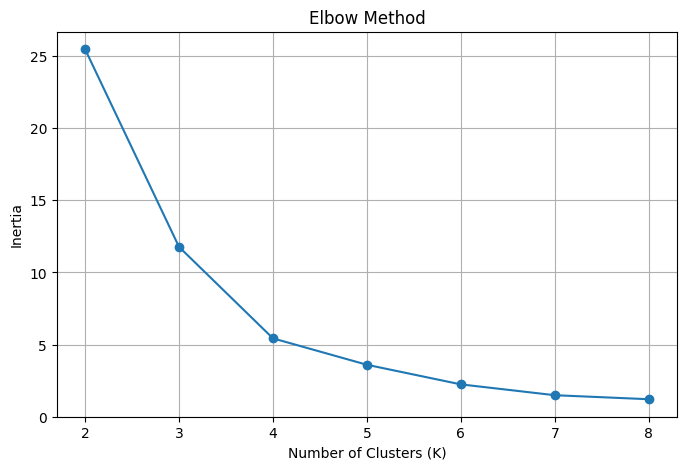

In [75]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Calculate inertia for K = 2 to 8
inertias = []
k_values = range(2, 9)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

# Display inertia values
for k, inertia in zip(k_values, inertias):
    print(f"K = {k}: Inertia = {inertia:.4f}")

# Plot Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.xticks(k_values)
plt.grid(True)
plt.show()

K = 2: Silhouette Score = 0.5448
K = 3: Silhouette Score = 0.5410
K = 4: Silhouette Score = 0.5091
K = 5: Silhouette Score = 0.4760
K = 6: Silhouette Score = 0.5001
K = 7: Silhouette Score = 0.4238
K = 8: Silhouette Score = 0.3547


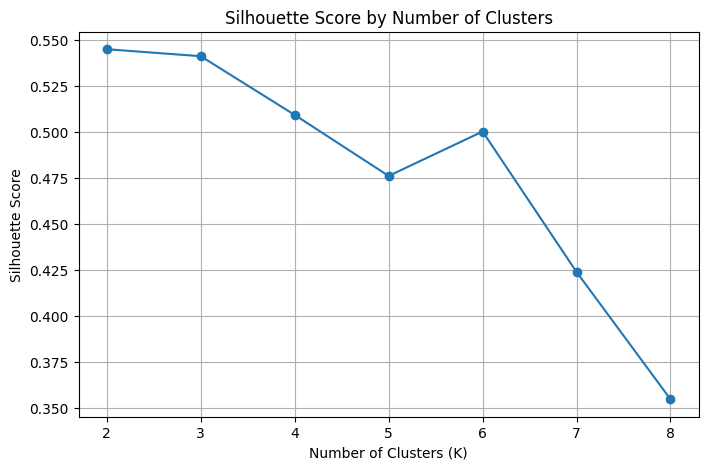

In [76]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 9):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

    print(f"K = {k}: Silhouette Score = {score:.4f}")

# Plot silhouette scores
plt.figure(figsize=(8, 5))
plt.plot(range(2, 9), silhouette_scores, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score by Number of Clusters")
plt.xticks(range(2, 9))
plt.grid(True)
plt.show()

In [77]:
# Final K-Means model with K = 4

kmeans_final = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans_final.fit_predict(X_scaled)

print("Cluster assignments:")
display(df)

Cluster assignments:


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Cluster
0,8500,4200,6800,2100,1800,950,2
1,12500,6200,9100,3400,3200,1450,3
2,5200,2800,4300,1500,900,620,1
3,16800,7900,11500,4200,4600,2100,0
4,9200,5100,7600,2800,2400,1200,2
5,13500,6800,9800,3600,3500,1700,3
6,6400,3500,5200,1900,1100,700,1
7,11200,5900,8300,3100,2900,1350,3
8,7400,3900,6100,2300,1500,850,2
9,18500,8500,12800,4800,5200,2400,0


In [78]:
print("Customers per cluster:")
print(df["Cluster"].value_counts().sort_index())

print("\nFinal Silhouette Score for K=4:")
final_silhouette = silhouette_score(X_scaled, df["Cluster"])
print(f"{final_silhouette:.4f}")

Customers per cluster:
Cluster
0    3
1    3
2    5
3    4
Name: count, dtype: int64

Final Silhouette Score for K=4:
0.5091


In [79]:
# Cluster profiling
cluster_profile = df.groupby("Cluster")[
    ["Fresh", "Milk", "Grocery", "Frozen", "Detergents_Paper", "Delicassen"]
].mean()

print("Average spending by cluster:")
display(cluster_profile.round(2))

Average spending by cluster:


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Cluster,,,,,,
0,16600.0,7866.67,11566.67,4300.0,4566.67,2116.67
1,5800.0,3100.00,4733.33,1700.0,1000.00,656.67
2,8640.0,4480.00,6840.00,2460.0,1900.00,990.00
3,12275.0,6100.00,8975.00,3350.0,3150.00,1475.00


In [80]:
# Number of customers and average spending by cluster
cluster_summary = cluster_profile.copy()
cluster_summary.insert(
    0,
    "Customers",
    df["Cluster"].value_counts().sort_index()
)

display(cluster_summary.round(2))

,Customers,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Cluster,,,,,,,
0,3,16600.0,7866.67,11566.67,4300.0,4566.67,2116.67
1,3,5800.0,3100.00,4733.33,1700.0,1000.00,656.67
2,5,8640.0,4480.00,6840.00,2460.0,1900.00,990.00
3,4,12275.0,6100.00,8975.00,3350.0,3150.00,1475.00


In [81]:
from sklearn.decomposition import PCA

# Reduce 6 standardized features to 2 principal components
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Create PCA DataFrame
pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df["Cluster"] = df["Cluster"].values

print("Explained variance ratio:")
print(f"PC1: {pca.explained_variance_ratio_[0]:.4f}")
print(f"PC2: {pca.explained_variance_ratio_[1]:.4f}")

print(
    f"\nTotal variance explained by PC1 + PC2: "
    f"{pca.explained_variance_ratio_.sum():.4f}"
)

display(pca_df)

Explained variance ratio:
PC1: 0.9927
PC2: 0.0032

Total variance explained by PC1 + PC2: 0.9959


,PC1,PC2,Cluster
0,-1.263032,-0.339904,2
1,1.480121,0.045981,3
2,-4.275582,-0.155196,1
3,3.318535,-0.095465,0
4,0.017178,0.083537,2
5,2.073308,-0.016362,3
6,-2.955828,0.111684,1
7,0.916809,0.035819,3
8,-1.787168,0.166395,2
9,4.047025,-0.018247,0


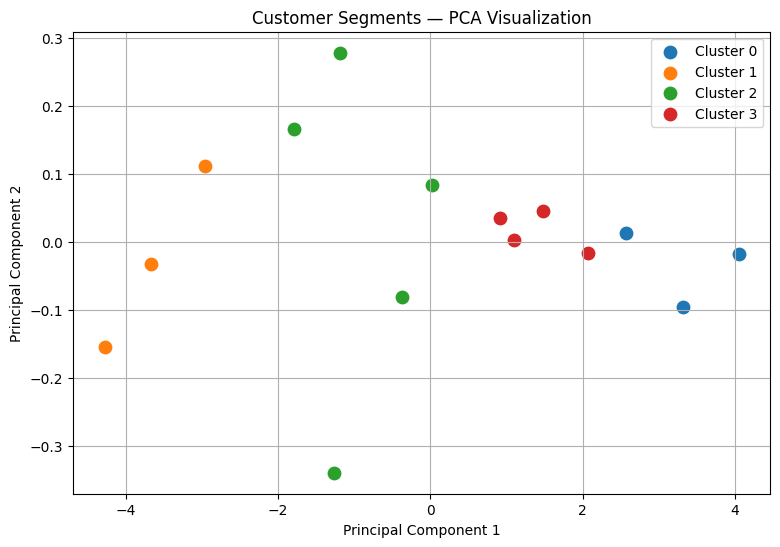

In [82]:
plt.figure(figsize=(9, 6))

for cluster in sorted(pca_df["Cluster"].unique()):
    cluster_data = pca_df[pca_df["Cluster"] == cluster]

    plt.scatter(
        cluster_data["PC1"],
        cluster_data["PC2"],
        label=f"Cluster {cluster}",
        s=80
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Customer Segments — PCA Visualization")
plt.legend()
plt.grid(True)
plt.show()

In [83]:
print("===== EXERCISE 5 FINAL RESULTS =====")

print(f"Dataset shape: {df.shape}")
print(f"Number of clusters: 4")
print(f"K=4 Silhouette Score: {final_silhouette:.4f}")

print("\nCluster sizes:")
print(df["Cluster"].value_counts().sort_index())

print("\nAcceptance Criteria:")
print(f"Silhouette >= 0.42: {'PASS' if final_silhouette >= 0.42 else 'FAIL'}")
print(f"K = 4: {'PASS' if 4 == 4 else 'FAIL'}")

===== EXERCISE 5 FINAL RESULTS =====
Dataset shape: (15, 7)
Number of clusters: 4
K=4 Silhouette Score: 0.5091

Cluster sizes:
Cluster
0    3
1    3
2    5
3    4
Name: count, dtype: int64

Acceptance Criteria:
Silhouette >= 0.42: PASS
K = 4: PASS


In [88]:
!find /content -maxdepth 2 -name "*.ipynb" -print